In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ShuffleSplit
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLTK Kneser-Ney interpolated (Hindle et al. ICSE 2012)
from nltk.lm import KneserNeyInterpolated, Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_sequence
from nltk.lm.vocabulary import Vocabulary
from nltk.util import ngrams

# Same filtering as a.ipynb

df = pd.read_csv("../../dataset/data/final_dataset_new_corrected.csv")
for col in ["doc_entropy", "doc_code_overlap", "doc_redundancy"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["doc_entropy", "doc_code_overlap", "doc_redundancy"])

agent_docs     = df[df["group"] == "agent"]["doc_text"].astype(str).tolist()
developer_docs = df[df["group"] == "human"]["doc_text"].astype(str).tolist()

agent_docs_gr10 = [doc for doc in agent_docs if len(doc.split()) >= 10]
developer_docs_gr10 = [doc for doc in developer_docs if len(doc.split()) >= 10]

print(f"Agent docs:     {len(agent_docs)}")
print(f"Developer docs: {len(developer_docs)}")
print(f"Agent docs >= 10 words:     {len(agent_docs_gr10)}")
print(f"Developer docs >= 10 words: {len(developer_docs_gr10)}")

agent_docs[:5]

Agent docs:     3744
Developer docs: 2177
Agent docs >= 10 words:     1966
Developer docs >= 10 words: 1259


['Generate suggestions based on semantic analysis of relationship types. Categorize relationships by semantic meaning Provide semantic category guidance',
 "Generate suggestions based on SFM business logic and domain constraints. SFM-specific institutional analysis patterns Hayden's institutional layer compatibility Economic flow patterns",
 'Generate suggestions based on entity type compatibility in SFM framework. Get entity type categories for analysis Suggest compatible entity combinations',
 'Categorize entity types for compatibility analysis.',
 'Basic relationship validation first Advanced consistency checks based on SFM principles Authority consistency: governance relationships require clear authority hierarchy Economic consistency: financial relationships require economic capability Temporal consistency: ensure entity lifecycles are compatible Structural entities (Resources, Systems) may have different temporal patterns This is acceptable but requires careful temporal modeling 

In [2]:
# Words appearing fewer than UNK_CUTOFF times in training are replaced with <UNK>.
# This ensures <UNK> has a non-zero count in training so test OOV words get
# a finite probability rather than zero (which would make entropy = inf).
UNK       = '<UNK>'
UNK_CUTOFF = 2


def train_lm(n, docs):
    """
    Train an order-n language model on whitespace-tokenized docs.
    Uses Kneser-Ney interpolated smoothing for n >= 2 (Hindle et al.);
    falls back to Laplace for n=1 since KN requires bigram context counts.
    """
    tokenized = [d.split() for d in docs if d.split()]

    # Build a vocabulary; mark words below cutoff as <UNK>
    all_words  = [w for sent in tokenized for w in sent]
    train_vocab = Vocabulary(all_words, unk_cutoff=UNK_CUTOFF)

    # Replace rare words with <UNK> in training sequences so the model
    # assigns a non-zero probability to <UNK> at test time
    tokenized_unk = [
        [w if w in train_vocab else UNK for w in sent]
        for sent in tokenized
    ]

    train_data, fitted_vocab = padded_everygram_pipeline(n, tokenized_unk)
    model = KneserNeyInterpolated(n) if n > 1 else Laplace(n)
    model.fit(train_data, fitted_vocab)
    return model, train_vocab


def doc_cross_entropy(model, train_vocab, doc, n):
    """
    Per-sample cross-entropy (bits) of a single doc under the given model.
    Matches Hindle et al.: log2, padded n-grams, mean over n-gram positions.
    """
    tokens = doc.split()
    if not tokens:
        return np.nan
    # Map OOV test tokens to <UNK> using the training vocabulary
    tokens = [w if w in train_vocab else UNK for w in tokens]
    padded = list(pad_sequence(
        tokens, n,
        pad_left=True,  left_pad_symbol='<s>',
        pad_right=True, right_pad_symbol='</s>',
    ))
    test_ngrams = list(ngrams(padded, n))
    if not test_ngrams:
        return np.nan
    try:
        ce = model.entropy(test_ngrams)   # returns bits (log2)
        return ce if np.isfinite(ce) else np.nan
    except (ZeroDivisionError, ValueError):
        return np.nan

In [3]:
# the following cell is used to train our model with 100 random sample validation and compute the 
# cross-entropy for each document in the test set. this cell uses our whole dataset
N_SPLITS = 100
records  = []


for n in range(1, 6):
    print(f"n={n}", end=" ", flush=True)
    for label, docs in [("Agent", agent_docs), ("Developer", developer_docs)]:
        arr = np.array(docs, dtype=object)
        ss = ShuffleSplit(n_splits=N_SPLITS, test_size=0.1, random_state=42) # split the data
        split = 1
        for train_idx, test_idx in ss.split(arr):
            model, train_vocab = train_lm(n, arr[train_idx])
            for doc_i, doc in zip(test_idx, arr[test_idx]):
                ce = doc_cross_entropy(model, train_vocab, doc, n)
                if not np.isnan(ce):
                    records.append({"n": n, "Group": label, "doc_id": int(doc_i), "cross_entropy": ce, "Split": split})
            split +=1
        print(".", end="", flush=True)
    print(" done")

results = pd.DataFrame(records)
print(f"\nTotal records: {len(results)}")
print(results.groupby(["n", "Group"]).size().unstack())

results.to_csv("n_gram_cross_entropy.csv", index=False)

n=1 .. done
n=2 .. done
n=3 .. done
n=4 .. done
n=5 .. done

Total records: 296500
Group  Agent  Developer
n                      
1      37500      21800
2      37500      21800
3      37500      21800
4      37500      21800
5      37500      21800


In [4]:
summary = (
    results.groupby(["n", "Group"])["cross_entropy"]
    .agg(mean="mean", std="std")
    .round(4)
)
print("Mean and Std of per-sample cross-entropy (bits) — Kneser-Ney interpolated")
print("=" * 60)
print(summary.to_string())

Mean and Std of per-sample cross-entropy (bits) — Kneser-Ney interpolated
               mean     std
n Group                    
1 Agent      9.3025  1.7175
  Developer  8.6779  1.8675
2 Agent      7.1578  2.3703
  Developer  6.2441  2.5156
3 Agent      6.6348  3.0249
  Developer  5.5133  3.3590
4 Agent      6.3874  3.0695
  Developer  5.2890  3.5201
5 Agent      6.1934  2.9956
  Developer  5.1385  3.4878


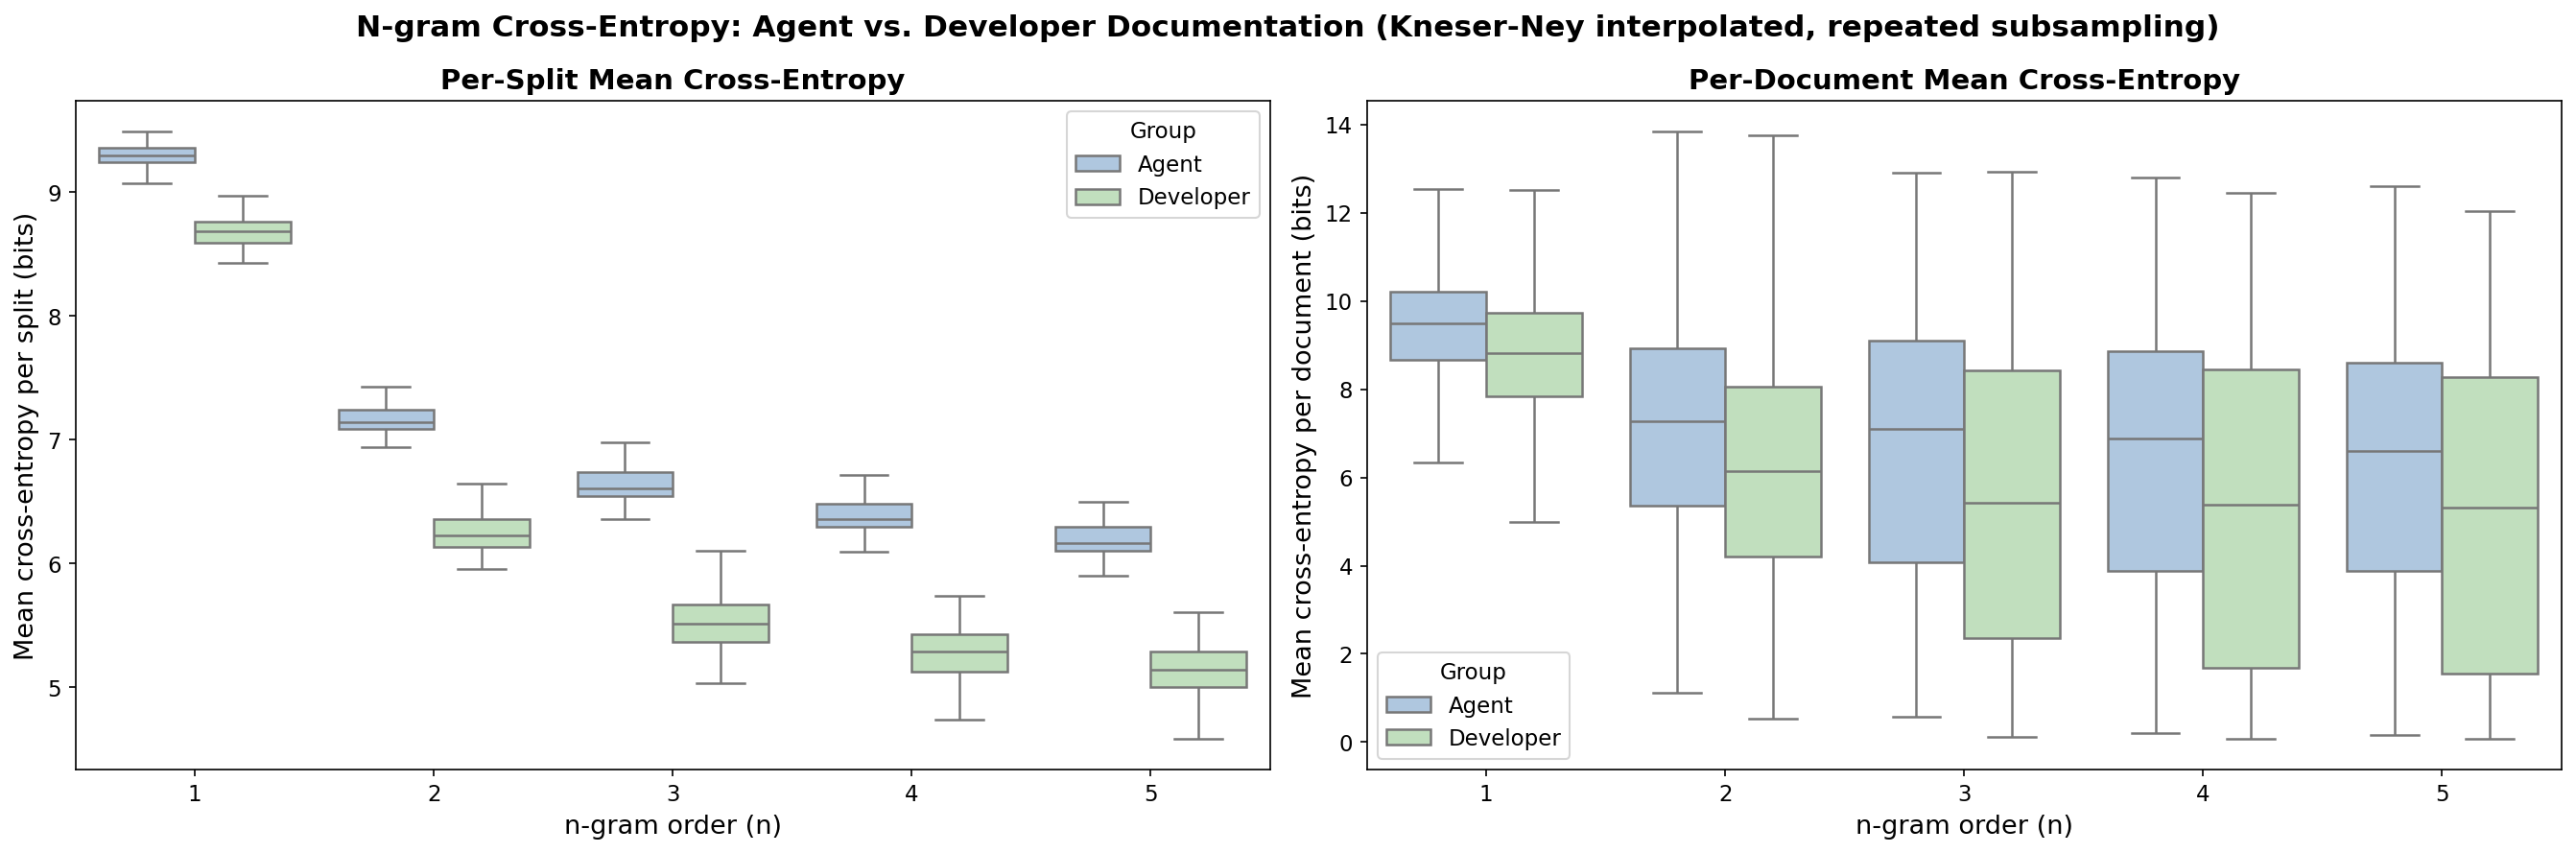


Mann-Whitney U (per-document collapse) and rank-biserial correlation:
  n=1: nag=3744 ndv=2177  p=3.8606e-60 ***  r_rb=-0.255
  n=2: nag=3744 ndv=2177  p=1.6547e-45 ***  r_rb=-0.220
  n=3: nag=3744 ndv=2177  p=1.4313e-39 ***  r_rb=-0.205
  n=4: nag=3744 ndv=2177  p=1.7018e-34 ***  r_rb=-0.191
  n=5: nag=3744 ndv=2177  p=3.1712e-32 ***  r_rb=-0.184

Per-split means (DIAGNOSTIC ONLY — not an independent-sample test, see note):
  n=1: nag=100 ndv=100  p=2.5621e-34 ***  r_rb=-1.000
  n=2: nag=100 ndv=100  p=2.5621e-34 ***  r_rb=-1.000
  n=3: nag=100 ndv=100  p=2.5621e-34 ***  r_rb=-1.000
  n=4: nag=100 ndv=100  p=2.5621e-34 ***  r_rb=-1.000
  n=5: nag=100 ndv=100  p=2.5621e-34 ***  r_rb=-1.000


In [5]:
results = pd.read_csv("n_gram_cross_entropy.csv")

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def rank_biserial(x, y, U=None):
    """Rank-biserial correlation effect size for Mann-Whitney U (Wendt, 1972)."""
    if U is None:
        U, _ = mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * U) / (len(x) * len(y))

palette = {"Agent": "#A7C7E7", "Developer": "#BDE5B8"}

# ---- collapse tables ----
per_doc = (results
    .groupby(["n", "Group", "doc_id"])["cross_entropy"]
    .mean()
    .reset_index())

per_split = (results
    .groupby(["n", "Group", "Split"])["cross_entropy"]
    .mean()
    .reset_index())

# ---- two side-by-side boxplots ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=150)

sns.boxplot(
    data=per_split, x="n", y="cross_entropy", hue="Group",
    palette=palette, showfliers=False, linewidth=1.2,
    order=[1, 2, 3, 4, 5], ax=axes[0],
)
axes[0].set_xlabel("n-gram order (n)", fontsize=13)
axes[0].set_ylabel("Mean cross-entropy per split (bits)", fontsize=13)
axes[0].set_title("Per-Split Mean Cross-Entropy", fontsize=14, fontweight="bold")
axes[0].legend(title="Group", fontsize=11, title_fontsize=11)
axes[0].tick_params(axis="both", labelsize=11)

sns.boxplot(
    data=per_doc, x="n", y="cross_entropy", hue="Group",
    palette=palette, showfliers=False, linewidth=1.2,
    order=[1, 2, 3, 4, 5], ax=axes[1],
)
axes[1].set_xlabel("n-gram order (n)", fontsize=13)
axes[1].set_ylabel("Mean cross-entropy per document (bits)", fontsize=13)
axes[1].set_title("Per-Document Mean Cross-Entropy", fontsize=14, fontweight="bold")
axes[1].legend(title="Group", fontsize=11, title_fontsize=11)
axes[1].tick_params(axis="both", labelsize=11)

fig.suptitle(
    "N-gram Cross-Entropy: Agent vs. Developer Documentation "
    "(Kneser-Ney interpolated, repeated subsampling)",
    fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.savefig("ngram_cross_entropy.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nMann-Whitney U (per-document collapse) and rank-biserial correlation:")
for n in range(1, 6):
    ag = per_doc[(per_doc["n"] == n) & (per_doc["Group"] == "Agent")]["cross_entropy"].values
    dv = per_doc[(per_doc["n"] == n) & (per_doc["Group"] == "Developer")]["cross_entropy"].values
    U, p = mannwhitneyu(ag, dv, alternative="two-sided")
    rbc = rank_biserial(ag, dv, U=U)
    print(f"  n={n}: nag={len(ag)} ndv={len(dv)}  p={p:.4e} {sig_label(p)}  r_rb={rbc:+.3f}")

print("\nPer-split means (DIAGNOSTIC ONLY — not an independent-sample test, see note):")
for n in range(1, 6):
    ag = per_split[(per_split["n"] == n) & (per_split["Group"] == "Agent")]["cross_entropy"].values
    dv = per_split[(per_split["n"] == n) & (per_split["Group"] == "Developer")]["cross_entropy"].values
    U, p = mannwhitneyu(ag, dv, alternative="two-sided")
    rbc = rank_biserial(ag, dv, U=U)
    print(f"  n={n}: nag={len(ag)} ndv={len(dv)}  p={p:.4e} {sig_label(p)}  r_rb={rbc:+.3f}")